In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the final cleaned dataset
df = pd.read_csv("/content/cleaned_healthcare_patients.csv")

print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Shape: (10000, 16)
Missing values: 0
Duplicate rows: 0


In [16]:
# Overall Healthcare Summar
summary = {
    "Total Patients": len(df),
    "Average Age": df["age"].mean(),
    "Average Risk Score": df["risk_score"].mean(),
    "Average Treatment Cost": df["treatment_cost"].mean(),
    "Average Length of Stay": df["length_of_stay"].mean(),
    "Readmission Rate (%)": (df["readmission"].eq("Yes").mean() * 100)
}

summary_df = pd.DataFrame(
    summary.items(),
    columns=["Metric", "Value"]
)

summary_df

,Metric,Value
0,Total Patients,10000.00000
1,Average Age,51.50670
2,Average Risk Score,46.41702
3,Average Treatment Cost,29963.90230
4,Average Length of Stay,6.50160
5,Readmission Rate (%),20.64000


In [17]:
# Disease-Level Insights
disease_summary = (
    df.groupby("disease")
      .agg(
          patient_count=("patient_id", "count"),
          avg_risk_score=("risk_score", "mean"),
          avg_treatment_cost=("treatment_cost", "mean"),
          avg_length_of_stay=("length_of_stay", "mean")
      )
      .sort_values("avg_risk_score", ascending=False)
)

disease_summary

,patient_count,avg_risk_score,avg_treatment_cost,avg_length_of_stay
disease,,,,
Cancer,638,67.864420,59879.951411,10.982759
Heart Disease,1146,63.226178,44144.046248,8.806283
Kidney Disease,674,59.619139,40529.280415,8.384273
Respiratory Disease,1121,42.813559,33915.394291,7.441570
Other,1131,41.462511,28385.069850,6.475685
Diabetes,1606,41.178954,25583.110212,5.878580
Hypertension,1884,40.572824,23144.032909,5.395966
Healthy/Preventive,1800,39.317500,15954.054444,3.885000


In [18]:
# Admission-Level Insights
admission_summary = (
    df.groupby("admission_type")
      .agg(
          patient_count=("patient_id", "count"),
          avg_risk_score=("risk_score", "mean"),
          avg_treatment_cost=("treatment_cost", "mean"),
          avg_length_of_stay=("length_of_stay", "mean")
      )
      .sort_values("avg_risk_score", ascending=False)
)

admission_summary

,patient_count,avg_risk_score,avg_treatment_cost,avg_length_of_stay
admission_type,,,,
Emergency,3164,53.099842,38217.848609,7.595765
Urgent,2472,44.608859,27853.851942,6.649676
Elective,4364,42.596059,25174.846013,5.624427


In [19]:
# Readmission Insights
readmission_summary = (
    df.groupby("readmission")
      .agg(
          patient_count=("patient_id", "count"),
          avg_risk_score=("risk_score", "mean"),
          avg_treatment_cost=("treatment_cost", "mean"),
          avg_length_of_stay=("length_of_stay", "mean")
      )
)

readmission_summary

,patient_count,avg_risk_score,avg_treatment_cost,avg_length_of_stay
readmission,,,,
No,7936,45.033140,28981.478075,6.299269
Yes,2064,51.737984,33741.285368,7.279554


In [20]:
# Smoking Status and Risk
smoking_summary = (
    df.groupby("smoking_status")
      .agg(
          patient_count=("patient_id", "count"),
          avg_risk_score=("risk_score", "mean"),
          avg_treatment_cost=("treatment_cost", "mean")
      )
      .sort_values("avg_risk_score", ascending=False)
)

smoking_summary

,patient_count,avg_risk_score,avg_treatment_cost
smoking_status,,,
Current,1733,51.018003,30208.918061
Former,2464,47.562500,29941.926136
Never,5803,44.556609,29900.062382


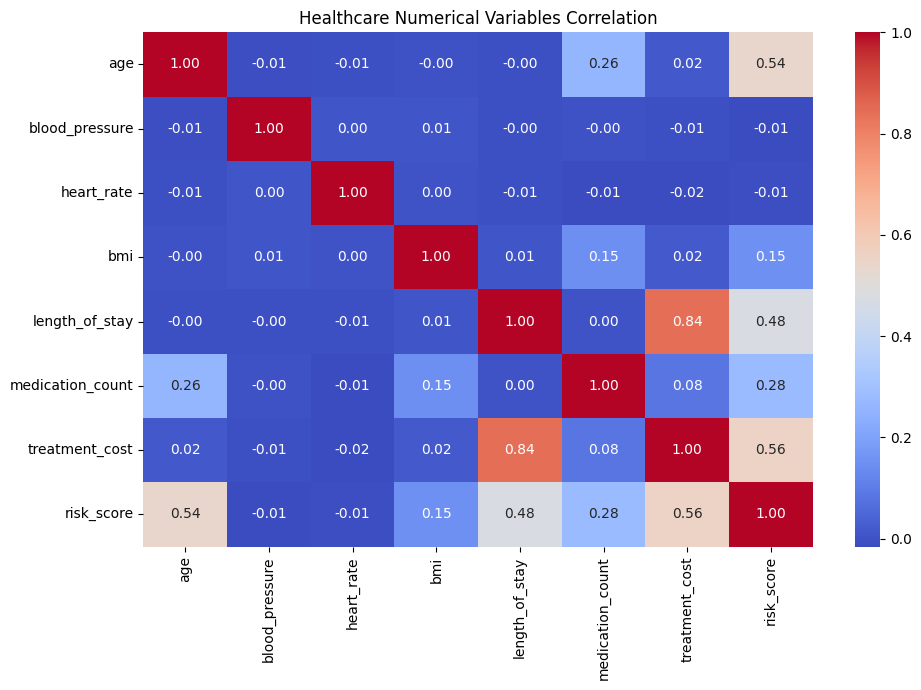

                       age  blood_pressure  heart_rate       bmi  \
age               1.000000       -0.011082   -0.006543 -0.000990   
blood_pressure   -0.011082        1.000000    0.004432  0.005067   
heart_rate       -0.006543        0.004432    1.000000  0.003954   
bmi              -0.000990        0.005067    0.003954  1.000000   
length_of_stay   -0.003837       -0.003885   -0.005320  0.007333   
medication_count  0.258895       -0.001317   -0.014063  0.146097   
treatment_cost    0.015820       -0.006293   -0.015408  0.016495   
risk_score        0.537061       -0.012683   -0.010472  0.149893   

                  length_of_stay  medication_count  treatment_cost  risk_score  
age                    -0.003837          0.258895        0.015820    0.537061  
blood_pressure         -0.003885         -0.001317       -0.006293   -0.012683  
heart_rate             -0.005320         -0.014063       -0.015408   -0.010472  
bmi                     0.007333          0.146097        0.016

In [24]:
# Correlation Summary
numerical_columns = [
    "age",
    "blood_pressure",
    "heart_rate",
    "bmi",
    "length_of_stay",
    "medication_count",
    "treatment_cost",
    "risk_score"
]

correlation_matrix = df[numerical_columns].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Healthcare Numerical Variables Correlation")
plt.tight_layout()
plt.show()

print(correlation_matrix)

In [22]:
# Key Statistical Findings
statistical_findings = pd.DataFrame({
    "Test": [
        "Readmission vs Risk Score",
        "Readmission vs Treatment Cost",
        "Risk Score across Diseases",
        "Treatment Cost across Admission Types",
        "Admission Type vs Readmission"
    ],
    "Test Type": [
        "Welch's t-test",
        "Welch's t-test",
        "One-way ANOVA",
        "One-way ANOVA",
        "Chi-square test"
    ],
    "P-value": [
        2.2567476715962e-48,
        8.014661525558531e-31,
        0.0,
        1.527e-321,
        2.3281677144359543e-06
    ]
})

statistical_findings

,Test,Test Type,P-value
0,Readmission vs Risk Score,Welch's t-test,2.256748e-48
1,Readmission vs Treatment Cost,Welch's t-test,8.014662e-31
2,Risk Score across Diseases,One-way ANOVA,0.000000e+00
3,Treatment Cost across Admission Types,One-way ANOVA,1.526663e-321
4,Admission Type vs Readmission,Chi-square test,2.328168e-06


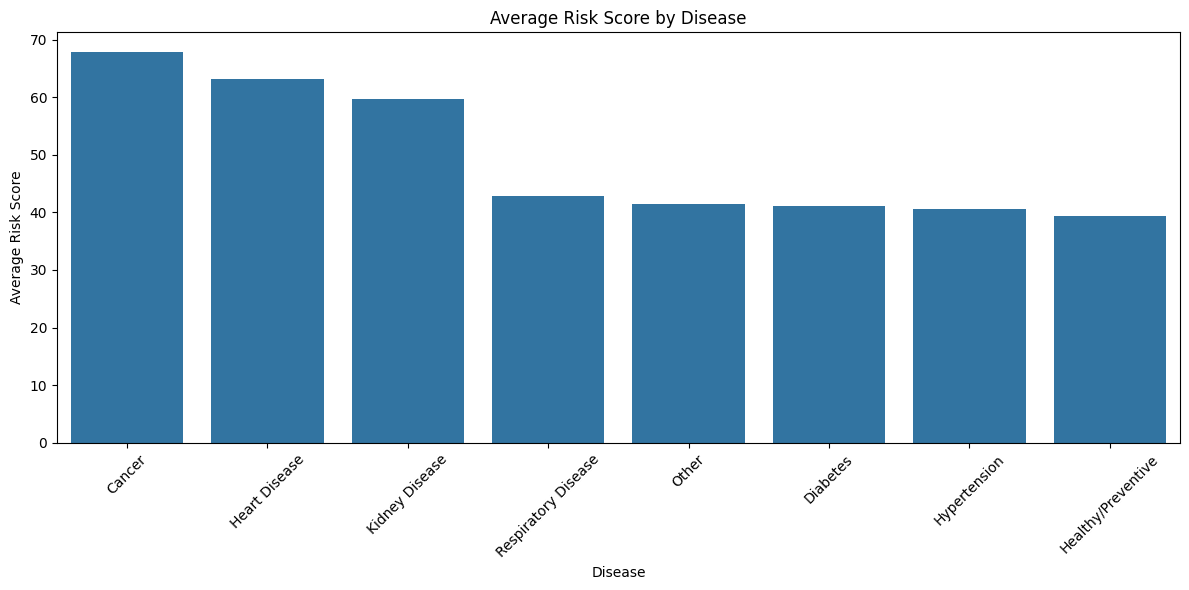

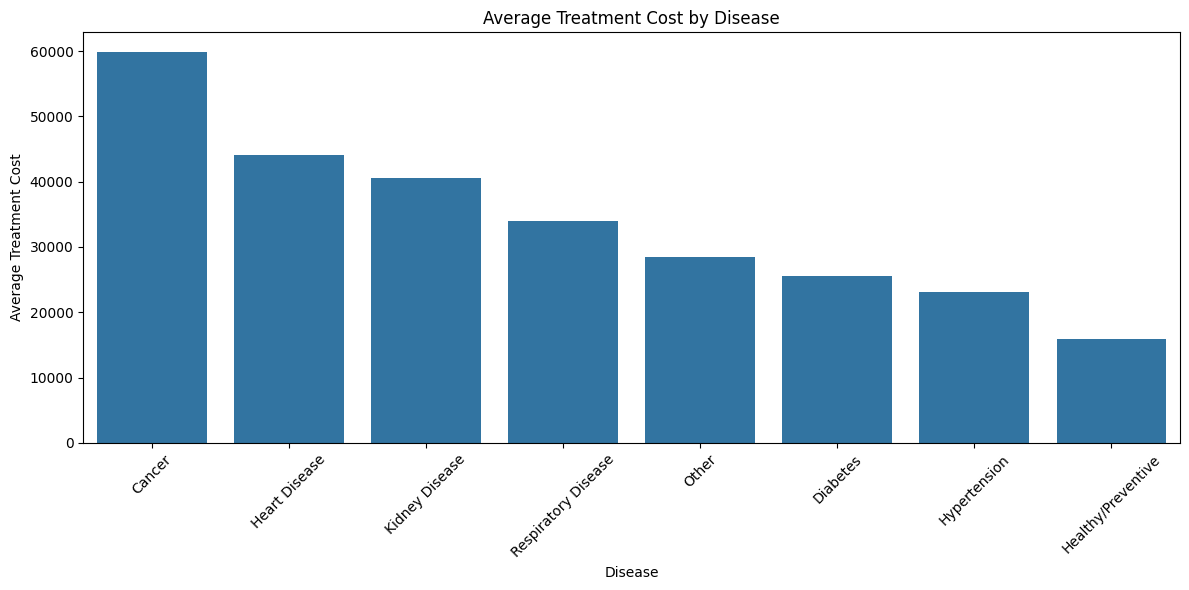

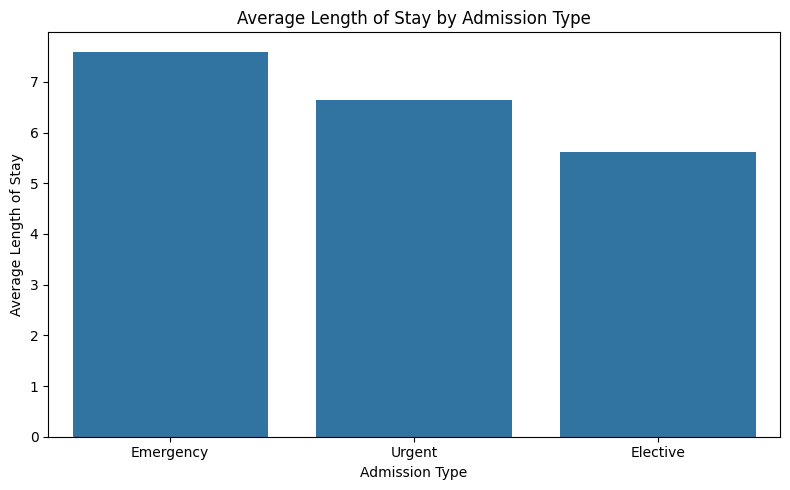

In [23]:
# Create Final Visualizations

# Disease vs Risk
plt.figure(figsize=(12, 6))

sns.barplot(
    data=disease_summary.reset_index(),
    x="disease",
    y="avg_risk_score"
)

plt.xticks(rotation=45)
plt.title("Average Risk Score by Disease")
plt.xlabel("Disease")
plt.ylabel("Average Risk Score")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))

sns.barplot(
    data=disease_summary.reset_index(),
    x="disease",
    y="avg_treatment_cost"
)

# Disease vs Treatment Cost
plt.xticks(rotation=45)
plt.title("Average Treatment Cost by Disease")
plt.xlabel("Disease")
plt.ylabel("Average Treatment Cost")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))

sns.barplot(
    data=admission_summary.reset_index(),
    x="admission_type",
    y="avg_length_of_stay"
)

# Admission vs Length of Stay
plt.title("Average Length of Stay by Admission Type")
plt.xlabel("Admission Type")
plt.ylabel("Average Length of Stay")
plt.tight_layout()
plt.show()

# Final Healthcare Analytics Insights

## 1. Patient Population
- The final cleaned dataset contains 10,000 patient records.
- The average patient age is approximately 51.5 years.
- The dataset contains patients across multiple disease and admission categories.

## 2. Disease Patterns
- Cancer patients had the highest average risk score.
- Cancer patients also had the highest average treatment cost.
- Cancer had the highest average length of stay.
- Healthy/Preventive patients had comparatively lower average risk, cost, and length of stay.

## 3. Admission Patterns
- Emergency admissions showed higher average risk scores than elective admissions.
- Emergency admissions had higher average treatment costs.
- Emergency admissions also had longer average hospital stays.

## 4. Readmission Patterns
- Readmitted patients had an average risk score approximately 6.70 points higher than non-readmitted patients.
- Readmitted patients had approximately ₹4,759.81 higher average treatment costs.
- Statistical testing showed significant differences between readmission groups for risk score and treatment cost.

## 5. Smoking Patterns
- Current smokers had the highest average risk score among smoking-status groups.
- This represents an observed association in the dataset and does not establish causation.

## 6. Correlation Findings
- Age and risk score showed a moderate positive correlation of approximately 0.54.
- Risk score and treatment cost showed a moderate positive correlation of approximately 0.56.

## 7. Statistical Findings
- Risk scores differed significantly across disease groups.
- Treatment costs differed significantly across admission types.
- Admission type and readmission status showed a statistically significant association.

## 8. Outlier Findings
- Treatment cost contained 195 IQR-based potential outliers.
- Length of stay contained 186 potential outliers.
- These observations were retained because extreme healthcare values may represent legitimate patient cases.

## 9. Overall Conclusion
The analysis identified meaningful relationships among disease type, admission type,
risk score, treatment cost, length of stay, smoking status, and readmission.
The findings describe patterns and associations within the dataset and should not
be interpreted as evidence of causation.